<a href="https://colab.research.google.com/github/shashisingh0015/bits/blob/main/Sem-1/ML/Assignment-1/Bike_Sharing_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
# importing libraries
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd

In [34]:
#importing datasets
data_set= pd.read_csv('/content/drive/MyDrive/Bits/ML/Lab-1/Assignment/bike_train.csv')

Let's first ensure the `datetime` column is correctly parsed and then extract the 'hour', 'weekday', 'month', and 'season' features.

In [36]:
#extract hour, weekday and month from datetime
data_set['datetime'] = pd.to_datetime(data_set['datetime'])

data_set['hour'] = data_set['datetime'].dt.hour
data_set['weekday'] = data_set['datetime'].dt.dayofweek
data_set['month'] = data_set['datetime'].dt.month

Preparation of data for the linear regression model by defining the features (X) and the target variable (y).

In [37]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = data_set[['hour', 'weekday', 'month', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']]
y = data_set['count']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (8360, 11)
Shape of X_test: (2090, 11)
Shape of y_train: (8360,)
Shape of y_test: (2090,)


In [38]:
#display sample X_train
X_train.head(5)

,hour,weekday,month,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
7293,1,4,12,4,0,1,2,10.353308,13.163035,73,13.771876
3012,16,2,8,3,0,1,1,31.160000,34.090000,48,12.998000
6649,17,2,10,4,0,1,1,22.140000,25.760000,56,7.001500
9528,2,3,10,4,0,1,1,18.860000,22.725000,67,12.998000
7453,2,0,10,4,0,1,1,23.464563,26.753311,56,25.314910


In [39]:
#display sample y_train
y_train.head(5)

,count
7293,55
3012,431
6649,888
9528,10
7453,35


The columns `hour`, `weekday`, `month`, `season`, `holiday`, `workingday`, and `weather` are indeed categorical, even though they are represented numerically.
For linear regression, it's often beneficial to convert these into one-hot encoded features. This prevents the model from interpreting these numerical values as having an ordinal relationship (e.g., that season 4 is 'greater' than season 1 in a linear sense).

Applying one-hot encoding to these columns for both the training and testing feature sets.

In [41]:
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer

# Identify categorical columns for one-hot encoding
categorical_cols = ['hour', 'weekday', 'month', 'season', 'holiday', 'workingday', 'weather']
# Identify numerical columns for polynomial features
numerical_cols = ['temp', 'atemp', 'humidity', 'windspeed']

# Create a ColumnTransformer to apply OneHotEncoder to categorical columns
# and PolynomialFeatures to numerical columns
# remainder='drop' ensures that only transformed columns are kept
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('poly', PolynomialFeatures(degree=2, include_bias=False), numerical_cols) # Apply polynomial features
    ],
    remainder='drop' # Drop any columns not explicitly specified
)

# Apply the transformation to the training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Apply the transformation to the test data
# Note: We use `transform` for the test set, not `fit_transform`,
# to ensure consistency with the encoding and polynomial features learned from the training set.
X_test_encoded = preprocessor.transform(X_test)

print(f"Shape of X_train after encoding and polynomial features: {X_train_encoded.shape}")
print(f"Shape of X_test after encoding and polynomial features: {X_test_encoded.shape}")

Shape of X_train after encoding and polynomial features: (8360, 69)
Shape of X_test after encoding and polynomial features: (2090, 69)


Now that our categorical features are one-hot encoded, we can proceed with training a Linear Regression model. We'll use the `LinearRegression` estimator from scikit-learn.

In [42]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model using the encoded training data
linear_reg_model.fit(X_train_encoded, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [43]:
print(linear_reg_model.coef_)

[-1.21542556e+02 -1.36211063e+02 -1.47577814e+02 -1.57102214e+02
 -1.56752731e+02 -1.41559464e+02 -8.13669628e+01  4.78803137e+01
  1.77057593e+02  3.59735414e+01 -1.35050010e+01  9.71734339e+00
  4.48849893e+01  3.93720948e+01  2.08689914e+01  2.71908063e+01
  9.30533093e+01  2.55756038e+02  2.17612567e+02  1.11845750e+02
  2.84154898e+01 -1.88760478e+01 -4.91698068e+01 -8.59651667e+01
 -2.40262520e+00 -4.74049451e+00  4.12368618e-01  5.41097602e+00
  2.46221784e+00  5.86471443e+00 -7.00715719e+00 -1.92446626e+01
 -8.07338418e+00  7.27333819e+00 -8.61115490e+00  1.90107164e+01
 -6.41915410e+00 -2.96916762e+01 -1.43613695e+01  3.63336723e+01
  1.68202166e+01  1.78536885e+00  5.17808905e+00 -2.00447086e+01
  3.98040742e+00 -7.71937335e+00  2.37836745e+01 -2.32570724e-03
  2.32570724e-03 -1.14011706e+00  1.14011706e+00  5.01429530e+01
  4.13278716e+01 -1.16944204e+00 -9.03013826e+01  2.16313473e+01
 -8.29399112e+00  4.48058352e+00  1.45281861e+00 -1.01520115e-01
 -4.29840381e-01 -9.58827

In [44]:
print(linear_reg_model.intercept_)

-136.74062971560596


## Ridge and Lasso Regression: Regularization Techniques

Ridge and Lasso (Least Absolute Shrinkage and Selection Operator) regression are extensions of linear regression. They are primarily used to address issues like overfitting, multicollinearity (when independent variables are highly correlated), and to perform feature selection.

Both methods work by adding a "penalty" term to the cost function of ordinary least squares (OLS) regression. This penalty shrinks the magnitude of the coefficients towards zero.

### 1. Ridge Regression (L2 Regularization)

*   **How it works:** Ridge regression adds a penalty equal to the square of the magnitude of the coefficients ($\alpha \sum_{j=1}^{p} \beta_j^2$) to the OLS cost function. The objective is to minimize:
    
    $$ \text{Loss} = \text{OLS Loss} + \alpha \sum_{j=1}^{p} \beta_j^2 $$
    
    where $\alpha$ (alpha) is the tuning parameter that controls the strength of the penalty. A larger $\alpha$ means more shrinkage.

*   **Effect:** It shrinks the coefficients of less important features towards zero but never exactly to zero. This means all features are kept in the model, but their impact is reduced. It's effective at reducing variance and preventing overfitting, especially when there are many features with small effects.

*   **Use cases:** When you suspect multicollinearity, or when you have many features and want to reduce their impact without eliminating any.

### 2. Lasso Regression (L1 Regularization)

*   **How it works:** Lasso regression adds a penalty equal to the absolute value of the magnitude of the coefficients ($\alpha \sum_{j=1}^{p} |\beta_j|$) to the OLS cost function. The objective is to minimize:
    
    $$ \text{Loss} = \text{OLS Loss} + \alpha \sum_{j=1}^{p} |\beta_j| $$

*   **Effect:** Similar to Ridge, Lasso shrinks coefficients. However, due to the absolute value penalty, it can shrink the coefficients of less important features exactly to zero. This effectively performs **feature selection**, removing those features from the model.

*   **Use cases:** When you have many features and want to identify the most important ones (sparse models), or when you want a simpler model by eliminating irrelevant features.

### Key Differences and the Role of $\alpha$

*   **Penalty Type:** Ridge uses L2 (squared magnitudes), Lasso uses L1 (absolute magnitudes).
*   **Feature Selection:** Ridge does not perform feature selection (coefficients approach zero but are rarely exactly zero). Lasso performs feature selection by setting coefficients to zero.
*   **Tuning Parameter ($\alpha$):** This hyperparameter is crucial for both. It determines the amount of regularization. You typically use techniques like cross-validation to find the optimal $\alpha$ value.

Now, let's implement these models.

Evaluation function

RMSLE = sqrt( (1/n) * Σ (log(pred+1) - log(actual+1))² )


In [49]:
#RMSLE function defination
def rmsle(y_true, y_pred):
 return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

In [50]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- Ridge Regression ---
print("\n--- Ridge Regression ---")

# Initialize the Ridge Regression model
# Alpha is the regularization strength. A common practice is to tune it using cross-validation.
# For now, we'll pick a starting value, e.g., 1.0. Experimentation is key!
ridge_model = Ridge(alpha=1.0, random_state=42)

# Train the model
ridge_model.fit(X_train_encoded, y_train)

# Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test_encoded)

# Evaluate the model
rmse_ridge = rmsle(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Model RMSE: {rmse_ridge:.2f}")
print(f"Ridge Model R-squared: {r2_ridge:.2f}")
print(f"Ridge Model Intercept: {ridge_model.intercept_:.2f}")
# Ridge coefficients are usually not zero, but smaller than OLS
# print(f"Ridge Model Coefficients (first 5): {ridge_model.coef_[:5].round(2)}")



--- Ridge Regression ---
Ridge Model RMSE: 0.82
Ridge Model R-squared: 0.64
Ridge Model Intercept: -123.68


/tmp/ipykernel_6950/3632473188.py:3: RuntimeWarning: invalid value encountered in log1p
  return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))


In [51]:
from sklearn.linear_model import Lasso

# --- Lasso Regression ---
print("\n--- Lasso Regression ---")

# Initialize the Lasso Regression model
# Alpha is the regularization strength. Again, typically tuned.
# Lasso can be sensitive to scaling, but OneHotEncoder and PolynomialFeatures already transform data.
lasso_model = Lasso(alpha=1.0, random_state=42, max_iter=2000) # Increased max_iter for convergence

# Train the model
lasso_model.fit(X_train_encoded, y_train)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test_encoded)

# Evaluate the model
rmse_lasso = rmsle(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Model RMSE: {rmse_lasso:.2f}")
print(f"Lasso Model R-squared: {r2_lasso:.2f}")
print(f"Lasso Model Intercept: {lasso_model.intercept_:.2f}")

# Check how many coefficients Lasso has shrunk to zero (feature selection)
zero_coeffs_lasso = np.sum(lasso_model.coef_ == 0)
print(f"Number of coefficients shrunk to zero by Lasso: {zero_coeffs_lasso}")

# print(f"Lasso Model Coefficients (first 5): {lasso_model.coef_[:5].round(2)}")



--- Lasso Regression ---
Lasso Model RMSE: 0.93
Lasso Model R-squared: 0.62
Lasso Model Intercept: -130.32
Number of coefficients shrunk to zero by Lasso: 31


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.556e+07, tolerance: 2.739e+04
  model = cd_fast.enet_coordinate_descent(
/tmp/ipykernel_6950/3632473188.py:3: RuntimeWarning: invalid value encountered in log1p
  return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))


### Residual Plot for Ridge Regression

A residual plot helps us to check the assumptions of linearity, homoscedasticity (constant variance of errors), and independence of errors. Ideally, residuals should be randomly scattered around zero, with no discernible patterns.

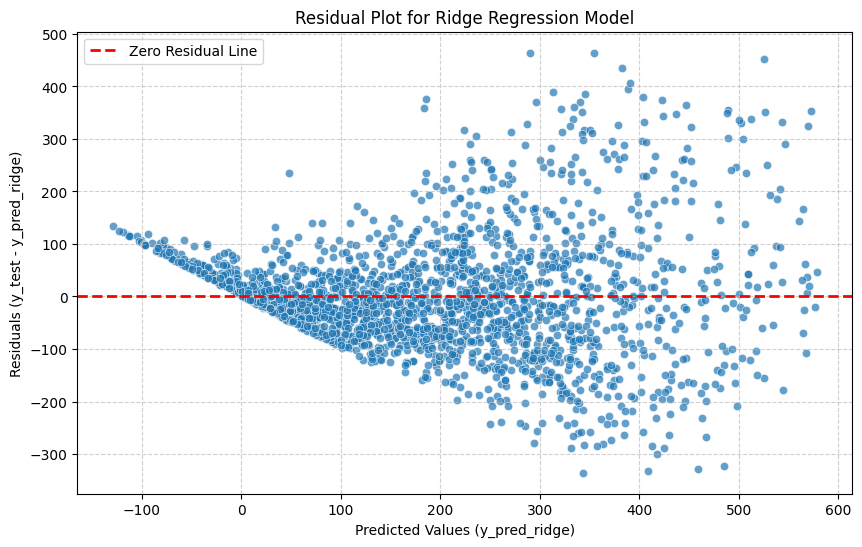

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for the Ridge model
residuals_ridge = y_test - y_pred_ridge

# Create a residual plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_ridge, y=residuals_ridge, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual Line')
plt.title('Residual Plot for Ridge Regression Model')
plt.xlabel('Predicted Values (y_pred_ridge)')
plt.ylabel('Residuals (y_test - y_pred_ridge)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()